In [108]:
import sys
print(sys.executable)

import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from random import random

from transformers import AutoModelForSequenceClassification
from transformers import AutoTokenizer, AutoConfig
import numpy as np
from scipy.special import softmax
from numpy import argmax
import config
import torch

import matplotlib.pyplot as plt
%pip install seaborn
import seaborn as sns
import random


c:\Users\annmarle\Desktop\Redditi postituste automaatne klassifitseerimine erineva signaalitasemega keskkondades\.venv\Scripts\python.exe
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [109]:
%pip install pandas
%pip install vaderSentiment
%pip install transformers
%pip install torch
%pip install skipy
%pip install matplotlib
%matplotlib inline
%pip install seaborn
%pip install config

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [114]:
# Eeltreenitud mudel
model_name = f"cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(model_name)
config = AutoConfig.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)


# Kommentaaride meelestatuse arvutamise funktsioon. 
# Sisend: rida
# Väljund : sõnastik {negatiivse_meelesatatuse_skoor, neutraalse_meelestatuse_skoor, positiivse_meelestatuse_skoor, peamine_meelestatus}
def comments_sentiment(row):
    # Parameetrid kaalutud keskmise arvutamiseks. Hoiavad endas kommentaaride meelestatuse skoori ja vastava kommentaari 'upvote' skoori korrutiste summat.
    neg_sum = 0.0
    neu_sum = 0.0
    pos_sum = 0.0
    scores_sum = 0.0

    comments = row["comments"]
    for comment in comments:
        comment_text = comment.get("body_original")
        # Kasutame 'upvote' skoori kaaluna, et populaarsemad kommentaarid mõjutaksid tulemust rohkem. 
        # Seetõttu võtame asendame 0 skoorid 1'ga, et vältida kommentaari väljajätmist arvutustest.
        score = max(1, comment.get("score"))

        if not comment_text or not comment_text.strip():
            continue

        # Teksti tokeniseerimine mudelile sobivaks kujuks.
        encoded_input = tokenizer(
            comment_text, 
            return_tensors='pt', 
            truncation=True, 
            max_length=512)
        
        # Jätame gradientide  arvutamise ära, sest me ei treeni mudelit, vaid kasutame seda ainult ennustamiseks.
        with torch.no_grad(): 
            output = model(**encoded_input)
        #print(output) 

        # Teisendame mudeli väljundid softmaxi abil 0-1 vahemikku.
        sentiment_scores = output[0][0].detach().numpy()
        sentiment_scores = softmax(sentiment_scores)

        # Korrutame iga meelestatuse skoori sellele vastava kommentaari 'upvote' skooriga ning liidame postituse kõikide kommentaaride tulemused kokku.
        neg_sum += sentiment_scores[0] * score
        neu_sum += sentiment_scores[1] * score
        pos_sum += sentiment_scores[2] * score
        scores_sum += score

    # Arvutame kaalutud keskmise
    if scores_sum > 0:
        neg_avg = neg_sum / scores_sum
        neu_avg = neu_sum / scores_sum
        pos_avg = pos_sum / scores_sum
    else:
        neg_avg = 0
        neu_avg = 1  # Kui kommentaarid puuduvad, siis jätame meelestatuse neutraalseks.
        pos_avg = 0

    # Leiame domineeriva meelestatuse.
    label_index = argmax([neg_avg, neu_avg, pos_avg])
    label = config.id2label[label_index]

    return{
        "Negative": round(neg_avg, 4),
        "Neutral": round(neu_avg, 4),
        "Positive": round(pos_avg, 4),
        "label": label
    }


# Postituste meelestatuse arvutamise funktsioon.
# Sisend: rida
# Väljund : sõnastik {negatiivse_meelesatatuse_skoor, neutraalse_meelestatuse_skoor, positiivse_meelestatuse_skoor, peamine_meelestatus}
def post_sentiment(row):
    # Kombineerime postituse pealkirja ning sisu.
    title = row["title_original"]
    selftext = row["selftext_original"]
    post_text = title + " " + selftext

    encoded_input = tokenizer(
        post_text, 
        return_tensors='pt', 
        truncation=True, 
        max_length=512
        )

    # Jätame gradientide  arvutamise ära, sest me ei treeni mudelit, vaid kasutame seda ainult ennustamiseks.
    with torch.no_grad(): 
        output = model(**encoded_input)

    # Teisendame mudeli väljundid softmaxi abil 0-1 vahemikku.
    sentiment_scores = output[0][0].detach().numpy()
    sentiment_scores = softmax(sentiment_scores)

    # Leiame meelestatuse skoorid.
    neg_score = round(sentiment_scores[0], 4)
    neu_score = round(sentiment_scores[1], 4)
    pos_score = round(sentiment_scores[2], 4)

    # Leiame domineeriva meelestatuse.
    label_index = argmax([neg_score, neu_score, pos_score])
    label = config.id2label[label_index]

    return {
        "Negative": neg_score,
        "Neutral": neu_score,
        "Positive": pos_score,
        "label": label
    }

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 781.39it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [117]:
# Loeme andmed sisse
# data_low sisaldab madala signaalitasemega postitusi, mis on puhastatud ning igale postitusele on määratud postituse tüüp (arvamuspostitus või küsimus).
# data_high sisaldab kõrge signaalitasemega postitusi, mis on puhastatud ning igale postitusele on määratud postituse tüüp (arvamuspostitus või küsimus).
data_low = pd.read_json("../data/labeled/labeled_clean_low.json")
data_high = pd.read_json("../data/labeled/labeled_clean_high.json")

randomStates = []
all_results = []

# Teeme mitu iterratsiooni, et tasakaalustada kõrge ja madala signaalitasemega postituste analüüsi jaoks.
for i in range(2):
    random_state = random.randint(0, 100)
    while True:
        # Kontrollime, et sama juhuvalim ei korduks.
        if random_state in randomStates:
            random_state = random.randint(0, 100)
            continue
        else:
            randomStates.append(random_state)

            # Võtame kõrge signaalitasemega postitustest juhuvalimi, milles suurus on võrne madala signaalitasemega postituste arvuga.
            data_high_sample = data_high.sample(n=len(data_low), random_state=random_state)
            data = pd.concat([data_low,data_high_sample]).reset_index().drop(columns="index")


            # Leiame kommentaaride ja postituste meelestatuse skoorid.
            data["comments_sentiment"] = data.apply(comments_sentiment, axis=1).copy()
            data["post_sentiment"] = data.apply(post_sentiment, axis=1).copy()

            # Eraldame andmed arvamuspostitusteks ja küsimsuteks.
            data_opinion = data[data["label"] == "expressing an opinion, complaint, praise, or personal experience"].copy()
            data_question = data[data["label"] == "asking for help, advice, recommendations, or comparison"].copy()

            # Arvamuspostitus
            # Avamuspostituse puhul võtame arvesse peamiselt autori enda arvamust, kuid kommentaarid mõjutavad siiski tulemust.
            # Lõplik meelestatus arvutatakse järgmiselt: postituse meelestatus * 0.6 + kommentaaride meelestatus * 0.4
            if not data_opinion.empty:
                data_opinion["final_negative"] = data_opinion.apply(lambda row: (row["post_sentiment"]["Negative"] * 0.6 + row["comments_sentiment"]["Negative"] * 0.4),  axis=1)
                data_opinion["final_neutral"] = data_opinion.apply(lambda row: (row["post_sentiment"]["Neutral"] * 0.6 + row["comments_sentiment"]["Neutral"] * 0.4), axis=1)
                data_opinion["final_positive"] = data_opinion.apply(lambda row: (row["post_sentiment"]["Positive"] * 0.6 + row["comments_sentiment"]["Positive"] * 0.4) , axis=1)
                data_opinion["final_label_post"] = data_opinion.apply(lambda row: config.id2label[argmax([row["final_negative"], row["final_neutral"], row["final_positive"]])], axis=1)

            # Küsimuspostitus
            # Küsimuspostuse puhul võtame arvesse peamiselt kommentaaride meelestatust, kuid postituse enda meelestatus mõjutab siiski tulemust.
            # Lõplik meelestatus arvutatakse järgmiselt: postituse meelestatus * 0.2 + kommentaaride meelestatus * 0.8
            if not data_question.empty:
                data_question["final_negative"] = data_question.apply(lambda row: row["post_sentiment"]["Negative"] * 0.2 + row["comments_sentiment"]["Negative"] * 0.8, axis=1)
                data_question["final_neutral"] = data_question.apply(lambda row: row["post_sentiment"]["Neutral"] * 0.2 + row["comments_sentiment"]["Neutral"] * 0.8, axis=1)
                data_question["final_positive"] = data_question.apply(lambda row: row["post_sentiment"]["Positive"] * 0.2 + row["comments_sentiment"]["Positive"] * 0.8, axis=1)
                data_question["final_label_post"] = data_question.apply(lambda row: config.id2label[argmax([row["final_negative"], row["final_neutral"], row["final_positive"]])], axis=1)
            
            # Ühendame arvamuspostitused ja küsimuspostitused.
            data_final = pd.concat([data_opinion, data_question], ignore_index=True)


            # Leiame iga subredditi meelestuse skoorid
            # Iga subredditi jaoks arvutame kaalutud keskmised upvote skoori põhjal. 
            subreddit_sentiment_negative = data_final.groupby("subreddit_name").apply(lambda group: (group["final_negative"] * group["score"].clip(lower=1)).sum() / group["score"].clip(lower=1).sum())
            subreddit_sentiment_neutral = data_final.groupby("subreddit_name").apply(lambda group: (group["final_neutral"] * group["score"].clip(lower=1)).sum() / group["score"].clip(lower=1).sum())
            subreddit_sentiment_positive = data_final.groupby("subreddit_name").apply(lambda group: (group["final_positive"] * group["score"].clip(lower=1)).sum() / group["score"].clip(lower=1).sum())
            subreddit_sentiment = pd.concat([
                    subreddit_sentiment_negative.rename("Negative"),
                    subreddit_sentiment_neutral.rename("Neutral"),
                    subreddit_sentiment_positive.rename("Positive")
                ], axis=1)
            
            # Leiame ifa subredditi domineeriva meelestatuse.
            subreddit_sentiment["main_sentiment"] = subreddit_sentiment.idxmax(axis=1)
            subreddit_sentiment = subreddit_sentiment.reset_index()
            
            subreddit_sentiment["random_state"] = random_state
            all_results.append(subreddit_sentiment)
            
            break

# Paneme kõik iteratsioonid kokku üheks tabeliks.
all_results_df = pd.concat(all_results, ignore_index=True)

# Leiame kõigi jooksude keksmise iga subredditi kohta
final_subreddit_summary = all_results_df.groupby("subreddit_name").agg(
    negative=("Negative", "mean"),
    neutral=("Neutral", "mean"),
    positive=("Positive", "mean")
).reset_index()

# Leiame iga subredditi peamise meelestatuse.
final_subreddit_summary["main_sentiment"] = final_subreddit_summary[
["negative", "neutral", "positive"]].idxmax(axis=1)

final_subreddit_summary["polarity"] = final_subreddit_summary["positive"] - final_subreddit_summary["negative"]


In [103]:
all_results

[  subreddit_name  Negative   Neutral  Positive main_sentiment  random_state
 0        hubspot  0.322035  0.431097  0.246885        Neutral            96
 1      marketing  0.501185  0.358414  0.140357       Negative            96,
   subreddit_name  Negative   Neutral  Positive main_sentiment  random_state
 0        hubspot  0.333951  0.517798  0.148248        Neutral            17
 1      marketing  0.501185  0.358414  0.140357       Negative            17]

In [116]:
final_subreddit_summary

,subreddit_name,negative,neutral,positive,main_sentiment
0,CRM,0.181358,0.478819,0.339826,neutral
1,DigitalMarketing,0.172699,0.462035,0.365259,neutral
2,Entrepreneur,0.558361,0.353408,0.088232,negative
3,b2bmarketing,0.164616,0.470569,0.364809,neutral
4,hubspot,0.192188,0.491410,0.316398,neutral
5,marketing,0.471754,0.356156,0.172048,negative
6,sales,0.173704,0.220215,0.606080,positive
7,startups,0.125449,0.631944,0.242579,neutral
8,techsales,0.261671,0.458359,0.279975,neutral


In [ ]:
""""
def sentiment_scores(sentence):
    sid_obj = SentimentIntensityAnalyzer() 
    # The SentimentIntensityAnalyzer class provides a method called polarity_scores() 
    # that takes a piece of text as input and returns a dictionary containing the sentiment scores for the text. 
    # The dictionary contains four keys: neg, neu, pos, and compound.
    
    sentiment_dict = sid_obj.polarity_scores(sentence)

    print(f"Sentiment Scores: {sentiment_dict}")
    #print(f"Negative Sentiment: {sentiment_dict['neg']*100}%")
    #print(f"Neutral Sentiment: {sentiment_dict['neu']*100}%")
    #print(f"Positive Sentiment: {sentiment_dict['pos']*100}%")
    
    if sentiment_dict['compound'] >= 0.05:
        print("Overall Sentiment: Positive")
    elif sentiment_dict['compound'] <= -0.05:
        print("Overall Sentiment: Negative")
    else:
        print("Overall Sentiment: Neutral")
    
    return sentiment_dict
"""

In [ ]:
"""""
data["text"] =  data["title"] + " " + data["selftext"]
data.head()
data["VADER_scores"] = data["text"].apply(sentiment_scores)
data["VADER_neg"] = data["VADER_scores"].apply(lambda d: d["neg"])
data["VADER_neu"] = data["VADER_scores"].apply(lambda d: d["neu"])
data["VADER_pos"] = data["VADER_scores"].apply(lambda d: d["pos"])
data["VADER_compund"] = data["VADER_scores"].apply(lambda d: d["compound"])

def vader_label(comp):
    if comp >= 0.05:
        return "positive"
    if comp <= -0.05:
        return "negative"
    return "neutral"

data["vader_label"] = data["VADER_compund"].apply(vader_label)
"""

Sentiment Scores: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Overall Sentiment: Neutral
Sentiment Scores: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Overall Sentiment: Neutral
Sentiment Scores: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Overall Sentiment: Neutral
Sentiment Scores: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Overall Sentiment: Neutral
Sentiment Scores: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Overall Sentiment: Neutral
Sentiment Scores: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Overall Sentiment: Neutral
Sentiment Scores: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Overall Sentiment: Neutral
Sentiment Scores: {'neg': 0.25, 'neu': 0.75, 'pos': 0.0, 'compound': -0.25}
Overall Sentiment: Negative
Sentiment Scores: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Overall Sentiment: Neutral
Sentiment Scores: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Overall Sentiment: Neutral
Senti

In [85]:
data.head()

,id,subreddit_name,title,selftext,created_utc,score,url,permalink,text,VADER_scores,VADER_neg,VADER_neu,VADER_pos,VADER_compund,vader_label
0,1q5s3rg,Android,Breaking: Google will now only release Android...,,1767727264,1411,https://www.androidauthority.com/aosp-source-c...,/r/Android/comments/1q5s3rg/breaking_google_wi...,Breaking: Google will now only release Android...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0,1.0,0.0,0.0,neutral
1,1qhpget,Android,PSA: Nova Launcher added Facebook and Google A...,,1768878292,1204,https://lemdro.id/post/lemdro.id/35049920,/r/Android/comments/1qhpget/psa_nova_launcher_...,PSA: Nova Launcher added Facebook and Google A...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0,1.0,0.0,0.0,neutral
2,1q87eid,Android,Vietnam bans ADB and bootloader unlocked andro...,,1767962979,1136,https://vanban.chinhphu.vn/?pageid=27160&docid...,/r/Android/comments/1q87eid/vietnam_bans_adb_a...,Vietnam bans ADB and bootloader unlocked andro...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0,1.0,0.0,0.0,neutral
3,1qcwixx,Android,Mishaal Rahman is quitting the Android news world,,1768418298,855,https://x.com/MishaalRahman/status/20115154058...,/r/Android/comments/1qcwixx/mishaal_rahman_is_...,Mishaal Rahman is quitting the Android news wo...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0,1.0,0.0,0.0,neutral
4,1q4hbup,Android,Asus confirms discontinuation of Zenfone and R...,,1767605585,791,https://www.notebookcheck.net/Asus-confirms-di...,/r/Android/comments/1q4hbup/asus_confirms_disc...,Asus confirms discontinuation of Zenfone and R...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0,1.0,0.0,0.0,neutral


In [ ]:

MODEL = f"cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
config = AutoConfig.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

def polarity_scores_roberta(text):
    #text = preprocess(text)
    encoded_input = tokenizer(text, return_tensors='pt', truncation=True, max_length=512)
    output = model(**encoded_input)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)

    results = {
        "roberta_neg" : scores[0],
        "roberta_neu" : scores[1],
        "roberta_pos" : scores[2]
    }
    return results

data["roberta_scores"] = data["text"].apply(polarity_scores_roberta)
data["roberta_neg"] = data["roberta_scores"].apply(lambda d: d["roberta_neg"])
data["roberta_neu"] = data["roberta_scores"].apply(lambda d: d["roberta_neu"])
data["roberta_pos"] = data["roberta_scores"].apply(lambda d: d["roberta_pos"])

def find_label(row):
    label = row[["roberta_neg","roberta_neu","roberta_pos"]].idxmax()
    
    match label:
        case "roberta_neg":
            result = "negative"
        case "roberta_neu":
            result = "neutral"
        case "roberta_pos":
            result = "positive"
        case _:
            result = "unknown"

    return result
    
data["roberta_label"] = data.apply(find_label, axis=1)




Loading weights: 100%|██████████| 201/201 [00:00<00:00, 846.78it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [87]:
data.tail()

,id,subreddit_name,title,selftext,created_utc,score,url,permalink,text,VADER_scores,VADER_neg,VADER_neu,VADER_pos,VADER_compund,vader_label,roberta_scores,roberta_neg,roberta_neu,roberta_pos,roberta_label
395,1q8c380,GooglePixel,Body temperature option gone....,Went to use the thermometer today and noticed ...,1767974439,11,https://www.reddit.com/r/GooglePixel/comments/...,/r/GooglePixel/comments/1q8c380/body_temperatu...,Body temperature option gone.... Went to use t...,"{'neg': 0.035, 'neu': 0.866, 'pos': 0.099, 'co...",0.035,0.866,0.099,0.6409,positive,"{'roberta_neg': 0.6007176, 'roberta_neu': 0.37...",0.600718,0.379210,0.020073,negative
396,1q5crw6,GooglePixel,Does the original Tensor chip still handle mod...,Now that the Pixel 6a is nearly four years old...,1767686779,12,https://www.reddit.com/r/GooglePixel/comments/...,/r/GooglePixel/comments/1q5crw6/does_the_origi...,Does the original Tensor chip still handle mod...,"{'neg': 0.0, 'neu': 0.946, 'pos': 0.054, 'comp...",0.000,0.946,0.054,0.3939,positive,"{'roberta_neg': 0.1189522, 'roberta_neu': 0.79...",0.118952,0.793943,0.087105,neutral
397,1q4zccw,GooglePixel,2 Years of Pixel 8 Pro usage,Phone still quick and fast but somehow there a...,1767649953,14,https://www.reddit.com/r/GooglePixel/comments/...,/r/GooglePixel/comments/1q4zccw/2_years_of_pix...,2 Years of Pixel 8 Pro usage Phone still quick...,"{'neg': 0.047, 'neu': 0.855, 'pos': 0.099, 'co...",0.047,0.855,0.099,0.8503,positive,"{'roberta_neg': 0.7430795, 'roberta_neu': 0.21...",0.743079,0.215612,0.041308,negative
398,1q4afg3,GooglePixel,Camera Bar Separation P9PXL,"Hello, I've had my P9PXL for over a year and I...",1767582932,12,https://www.reddit.com/r/GooglePixel/comments/...,/r/GooglePixel/comments/1q4afg3/camera_bar_sep...,"Camera Bar Separation P9PXL Hello, I've had my...","{'neg': 0.08, 'neu': 0.92, 'pos': 0.0, 'compou...",0.080,0.920,0.000,-0.5574,negative,"{'roberta_neg': 0.812178, 'roberta_neu': 0.174...",0.812178,0.174148,0.013674,negative
399,1q44aq6,GooglePixel,Wanting to switch from iPhone 15Pro to Pixel 1...,I’ve had android in the past. And have been on...,1767567179,10,https://www.reddit.com/r/GooglePixel/comments/...,/r/GooglePixel/comments/1q44aq6/wanting_to_swi...,Wanting to switch from iPhone 15Pro to Pixel 1...,"{'neg': 0.063, 'neu': 0.795, 'pos': 0.142, 'co...",0.063,0.795,0.142,0.9857,positive,"{'roberta_neg': 0.12150259, 'roberta_neu': 0.6...",0.121503,0.633628,0.244870,neutral


In [88]:
data["same_label"] = data["vader_label"] == data["roberta_label"]
data["same_label"].value_counts(normalize=True)


same_label
True     0.5125
False    0.4875
Name: proportion, dtype: float64

In [97]:
ct = pd.crosstab(data["vader_label"], data["roberta_label"])


In [90]:
data["vader_label"].value_counts(normalize=True)

vader_label
positive    0.5025
neutral     0.2575
negative    0.2400
Name: proportion, dtype: float64

In [91]:
data["roberta_label"].value_counts(normalize=True)

roberta_label
neutral     0.455
negative    0.285
positive    0.260
Name: proportion, dtype: float64

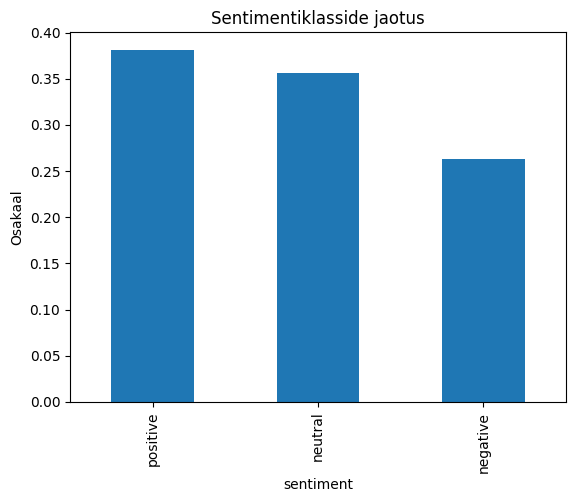

In [ ]:

dist_df = (
    data[["vader_label", "roberta_label"]]
    .melt(var_name="model", value_name="sentiment")
)

dist_df["model"] = dist_df["model"].map({
    "vader_label": "VADER",
    "roberta_label": "RoBERTa"
})

plt.figure()
dist_df["sentiment"].value_counts(normalize=True).plot(kind="bar")
plt.title("Sentimentiklasside jaotus")
plt.ylabel("Osakaal")
plt.show()


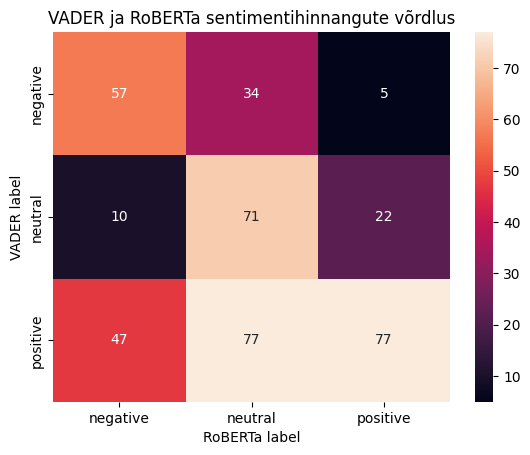

In [ ]:
ct = pd.crosstab(data["vader_label"], data["roberta_label"])


plt.figure()
sns.heatmap(
    ct,
    annot=True,
    fmt="d",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"]
)
plt.xlabel("RoBERTa label")
plt.ylabel("VADER label")
plt.title("VADER ja RoBERTa sentimentihinnangute võrdlus")
plt.show()
